### Smart Customer Support Bot (LangGraph)


In [19]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict,Literal
from dotenv import load_dotenv
import os
load_dotenv()

True

In [20]:
api_key = os.getenv("GROQ_API_KEY")
llm= ChatGroq(api_key=api_key,model='llama-3.1-8b-instant')

In [21]:
class SupportState(TypedDict, total=False):
    
    user_input: str
    classify: Literal['order','general','refund','complaint']
    order: str
    general: str
    refund: str
    complaint:str

In [22]:
def Classifier_Node(state):
    user = state['user_input']

    prompt = f"""
    Classify the following user message into only one category 
    Order,Refund,Genral,Complaint.

    \n\nMessage= {user}

    return only category name
    """
    response = llm.invoke(prompt).content.strip().lower()
    if response not in ['order','general','refund','complaint']:
        response = 'general'
    return {'classify': response}


def check_condition(state: SupportState)-> Literal['Order_Node','General_Node','Refund_Node','Complaint_Node']:

    category  = state['classify'].strip().lower()
    if category == 'order':
        return 'Order_Node'
    elif category == 'refund':
        return 'Refund_Node'
    elif category == 'complaint':
        return 'Complaint_Node'
    else:
        return 'General_Node'


def Order_Node(state: SupportState):

    order = state['user_input']

    prompt = f""" 
    Based on the category: {order}

    Select ONLY ONE status from the list below:
    1. Order Confirmed
    2. Shipped Expected 
    3. Out For Delivery

    Rules:
    - Return only ONE status (exact text)
    - Add a short description (1–2 lines)
    - Do NOT add extra text

    Output format:
    Status: <one status>
          - Description: <short description>
    """

    response = llm.invoke(prompt).content

    return {'order': response}


def General_Node(state: SupportState):

    general = state['user_input']

    prompt = f"""
   You are a human-like chatbot for online platforms (Flipkart, Amazon, Meesho, etc.).  

    Your task:
    - Answer customer queries naturally and helpfully based on {general}.  
    - Provide clear, concise, and friendly responses.  
    - If the query involves Refund or Cancellation, respond according to standard platform policies.  

    Output format:

    AI: <Output>
    """

    response = llm.invoke(prompt).content

    return {'general': response}

def Refund_Node(state: SupportState):

    refund = state['user_input']

    prompt = f"""
    You are a Flipkart Refund & Cancellation Manager.  

    A customer has requested a refund. Use the information from the classifier: {refund} to decide the outcome.

    Rules:
    1. Determine if the refund request should be Approved or Rejected based on standard Flipkart policies (e.g., order status, return window, payment method).
    2. If Approved:
        - Provide a concise reason why the refund is approved.
    3. If Rejected:
        - Provide a concise reason why the refund is rejected.

    Output format:

    Status: <Approved> or <Rejected>
    - Description: <short description>
    """

    response = llm.invoke(prompt).content

    return {'refund': response}

def Complaint_Node(state: SupportState):

    complaint = state['user_input'] 

    prompt = """ 
    You are a Customer Support Complaint Manager for an e-commerce platform
    (Flipkart, Amazon, Meesho).

    Customer complaint:
    "{complaint}"

    Your task:
    - Acknowledge the complaint politely.
    - Apologize for the inconvenience.
    - Assure the customer that the issue will be resolved.
    - Suggest the next action (refund, replacement, escalation, or support ticket).

    Rules:
    - Be professional and human-like.
    - Do NOT promise unrealistic things.
    - Keep the response short and clear.

    Output format:

    AI: <complaint response>

    """

    response = llm.invoke(prompt).content

    return {'complaint':response}



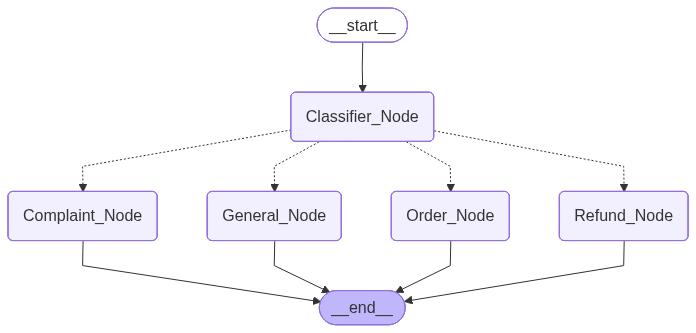

In [23]:
graph = StateGraph(SupportState)

graph.add_node("Classifier_Node",Classifier_Node)
graph.add_node("Order_Node",Order_Node)
graph.add_node('General_Node',General_Node)
graph.add_node('Refund_Node',Refund_Node)
graph.add_node('Complaint_Node',Complaint_Node)


graph.add_edge(START, "Classifier_Node")

graph.add_conditional_edges('Classifier_Node', check_condition)
graph.add_edge('Order_Node', END)
graph.add_edge('General_Node', END)
graph.add_edge('Refund_Node', END)
graph.add_edge('Complaint_Node', END)

chatbot = graph.compile()
chatbot

In [36]:
initial_state={'user_input': "can you change my no."}

response = chatbot.invoke(initial_state)
response
print('User Input:', response['user_input'])

if "general" in response and response["general"]:
    print("Bot Reply :",response['general'])

elif "refund" in response and response['refund']:
    print("Refund Reply:", response['refund'])
    
elif "complaint" in response and response['complaint']:
    print("Complaint Reply:", response['complaint'])
else:
    print("Order Reply:", response['order'])

User Input: can you change my no.
Bot Reply : I'm here to help you with any queries you may have. How can I assist you today?
